In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter

import re 

## Plot results from Popham-style conditions 

## Set paths and pick model 

In [2]:
parent_path = Path('/om2/user/imgriff/projects/torch_2_aud_attn/popham_mono_eval/')

model_name = 'word_task_quarter_co_loc_v08'

results_dirs = list(parent_path.rglob(f"*{model_name}"))
print(len(results_dirs))

12


In [3]:
results_dirs

[PosixPath('/om2/user/imgriff/projects/torch_2_aud_attn/popham_mono_eval/TIMIT_harmonic_speech_jitter_render_attn_task_0dB_SNR_all_targets_word_task_quarter_co_loc_v08'),
 PosixPath('/om2/user/imgriff/projects/torch_2_aud_attn/popham_mono_eval/TIMIT_harmonic_speech_jitter_render_attn_task_clean_all_targets_word_task_quarter_co_loc_v08'),
 PosixPath('/om2/user/imgriff/projects/torch_2_aud_attn/popham_mono_eval/TIMIT_harmonic_target_inharmonic_distractor_attn_task_0dB_SNR_all_targets_word_task_quarter_co_loc_v08'),
 PosixPath('/om2/user/imgriff/projects/torch_2_aud_attn/popham_mono_eval/TIMIT_harmonic_target_whispered_distractor_attn_task_0dB_SNR_all_targets_word_task_quarter_co_loc_v08'),
 PosixPath('/om2/user/imgriff/projects/torch_2_aud_attn/popham_mono_eval/TIMIT_inharmonic_speech_attn_task_0dB_SNR_all_targets_word_task_quarter_co_loc_v08'),
 PosixPath('/om2/user/imgriff/projects/torch_2_aud_attn/popham_mono_eval/TIMIT_inharmonic_speech_attn_task_clean_all_targets_word_task_quarter_c

### Get metadata for stimuli

In [4]:
## Model label dicts
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
class_map = word_and_speaker_encodings['word_idx_to_word']


# use new model map 
model_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
model_word_id_to_word = {v: k for k, v in model_class_map.items()}

In [5]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/harmonic_timit/')

harmonic_meta_data = pd.read_pickle(out_path / 'all_targets_harmonic_single_distractor_0dB_SNR_jitter_fn_render.pdpkl')

### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/inharmonic_timit/')

inharm_meta_data = pd.read_pickle(out_path / 'all_targets_inharmonic_single_distractor_0dB_SNR.pdpkl')

### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/whispered_timit/')

whisper_meta_data = pd.read_pickle(out_path / 'all_targets_whispered_single_distractor_0dB_SNR.pdpkl')

#### Def condition meta dict

In [6]:
## All conditions have the same meta data - could just use one in future
# Crossed conditions have identical metadata to non-crossed target dir 

cond_df_dict = {'harmonic': harmonic_meta_data, 'inharmonic': inharm_meta_data, 'whispered': whisper_meta_data}


### Combine all model results, adding metadata from stim manifest for each condition

In [7]:
results_df = []

for dir_path in results_dirs:
    file_path = list(dir_path.rglob("*.csv"))[-1] # get most recent results
    df = pd.read_csv(file_path)
    # rename columns 
    df = df.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in df.index})
    df['pred_word_ix'] = df['pred_word_ix'].astype('int') 
    
    # get harmonic condition from dir_path name
    harm_cond = dir_path.stem.split("_")[1]
    meta_df = cond_df_dict[harm_cond]

    snr = 'clean' if 'clean' in dir_path.stem else '0dB'
    # get distractor condition based on dir_path.stem
    if snr == 'clean':
        dist_cond = 'No Distractor'
        dist_cond_str = f"{harm_cond.title()} {dist_cond}"
    
    else:
        if 'distractor' in dir_path.stem:
            dist_cond = dir_path.stem.split('target_')[-1].split('_distractor')[0].title()
        else:
            dist_cond = harm_cond.title()

        dist_cond_str = f"{harm_cond.title()} target {dist_cond} distractor"

    df['target_condition'] = harm_cond.title()
    df['distractor_condition'] = dist_cond
    df['distractor_condition_str'] = dist_cond_str
    df['guessed_word'] = df['pred_word_ix'].map(model_word_id_to_word)
    
    if snr == 'clean':
        ### Get metadata from timit df 
        df['true_word'] = meta_df.loc[df.orig_df_ix, ['word']].values
        df['target_sex'] = meta_df.loc[df.orig_df_ix, ['speaker_sex']].values
  
    else:
        ### Get metadata from timit df 
        df['true_word'] = meta_df.loc[df.orig_df_ix, ['word']].values
        df['distractor_words'] = meta_df.loc[df.orig_df_ix, ['distractor_words']].values
        df['distractor_sex'] = meta_df.loc[df.orig_df_ix, ['distractor_sex']].values
        df['snr'] = meta_df.loc[df.orig_df_ix, ['snrs']].values.astype('str')
        df['target_sex'] = meta_df.loc[df.orig_df_ix, ['speaker_sex']].values

    results_df.append(df)

all_results = pd.concat(results_df, ignore_index=True)



get_confusion = lambda row: int(row.guessed_word in row.distractor_words) if not isinstance(row.distractor_words, float) else row.distractor_words

all_results['confusion'] = all_results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)
# drop oov trials

all_results = all_results[all_results.true_word_ix != -1]


In [9]:
all_results

,true_word_ix,orig_df_ix,model_confidence,accuracy,pred_word_ix,target_condition,distractor_condition,distractor_condition_str,guessed_word,true_word,distractor_words,distractor_sex,snr,target_sex,confusion
0,539.0,0,0.742047,1.0,539,Harmonic,Harmonic,Harmonic target Harmonic distractor,programs,programs,night,m,0,f,0.0
1,460.0,1,0.823278,0.0,0,Harmonic,Harmonic,Harmonic target Harmonic distractor,about,novel,present,m,0,f,0.0
2,617.0,2,0.082065,0.0,714,Harmonic,Harmonic,Harmonic target Harmonic distractor,through,should,always,m,0,f,0.0
3,632.0,3,0.216838,1.0,632,Harmonic,Harmonic,Harmonic target Harmonic distractor,social,social,would,f,0,f,0.0
4,375.0,4,0.718386,1.0,375,Harmonic,Harmonic,Harmonic target Harmonic distractor,light,light,common,m,0,f,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10818,382.0,896,0.297366,0.0,194,Whispered,Inharmonic,Whispered target Inharmonic distractor,division,living,others,m,0,m,0.0
10819,54.0,897,0.994557,1.0,54,Whispered,Inharmonic,Whispered target Inharmonic distractor,based,based,production,f,0,m,0.0
10820,210.0,898,0.133394,1.0,210,Whispered,Inharmonic,Whispered target Inharmonic distractor,either,either,would,m,0,m,0.0
10821,714.0,899,0.178484,0.0,98,Whispered,Inharmonic,Whispered target Inharmonic distractor,carried,through,theory,f,0,m,0.0


### Make heatmaps 

In [38]:
total_con

target_condition  distractor_condition
Harmonic          Harmonic                0.105793
                  Inharmonic              0.060453
                  Whispered               0.037783
                  No Distractor                NaN
Inharmonic        Harmonic                0.069270
                  Inharmonic              0.130982
                  Whispered               0.075567
                  No Distractor                NaN
Whispered         Harmonic                0.027708
                  Inharmonic              0.055416
                  Whispered               0.149874
                  No Distractor                NaN
Name: confusion, dtype: float64

In [42]:
to_plot[to_plot.distractor_condition != 'No Distractor'].distractor_condition.unique()

['Harmonic', 'Inharmonic', 'Whispered']
Categories (4, object): ['Harmonic', 'Inharmonic', 'Whispered', 'No Distractor']

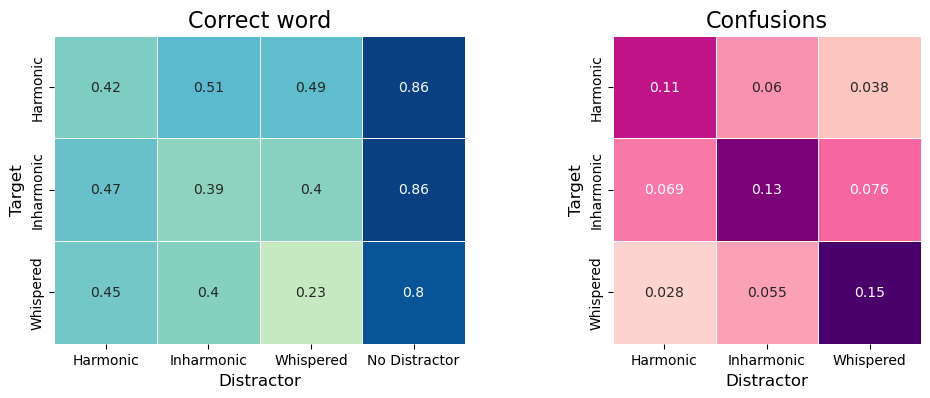

In [55]:

fontsize=16
to_plot = all_results.copy()
to_plot.distractor_condition = pd.CategoricalIndex(to_plot.distractor_condition, categories=['Harmonic', 'Inharmonic', 'Whispered', 'No Distractor'])
to_plot.sort_values('distractor_condition', inplace=True)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharex=False, sharey=False)

# cbar_ax_1 = fig.add_axes([.91, .56, .02, .3])
# cbar_ax_2 = fig.add_axes([.91, .14, .02, .3])
# make heatmpas square 
axs[0].set_aspect('equal')
axs[1].set_aspect('equal')

# scale size of  colorbar to match heatmap
cbar_kws = {"shrink": .7,}

total_acc = to_plot.groupby(["target_condition", "distractor_condition"])['accuracy'].mean()
sns.heatmap(total_acc.unstack(), vmin=0, vmax=total_acc.max(), annot=True, cmap='GnBu', cbar=False, linewidth=.5, ax=axs[0])

total_con = all_results[all_results.distractor_condition != 'No Distractor'].groupby(['target_condition', 'distractor_condition'])['confusion'].mean()
sns.heatmap(total_con.unstack(), vmin=0, vmax=total_con.max(), annot=True, cmap='RdPu', cbar=False, linewidth=.5,  ax=axs[1]) # cbar_kws=cbar_kws,

axs[0].set_title("Correct word", fontsize=fontsize)#xy=(0.5, 1), xytext=(0, 5), size='large', ha='center', va='baseline', xycoords='axes fraction', textcoords='offset points',)
# for ax, row in zip(axs[1], rows):
axs[1].set_title("Confusions", fontsize=fontsize) # , xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0), xycoords=ax.yaxis.label, textcoords='offset points', size='large', ha='right', va='center', rotation=90)

# change axis labels for both heatmaps
for ax in axs:
    # ax.set_xticklabels(np.arange(-90, 91, 30), fontsize=fontsize-4)
    # ax.set_yticklabels(np.arange(-90, 91, 30), fontsize=fontsize-4)
    ax.set_xlabel('Distractor', fontsize=fontsize-4)
    ax.set_ylabel('Target', fontsize=fontsize-4)

# axs[0].set_xlabel('Distractor conditionuth ($\degree$)', fontsize=fontsize-4)
# axs[0].set_ylabel('Target conditionuth ($\degree$)', fontsize=fontsize-4)

# fig.tight_layout(rect=[0,0,.9,1])
# plt.suptitle('50% co-located trials in training', fontsize=14, y=1.05)

# make colorbar match heatmap size

# set confusions colorbar ticks to 0.5 increments
# cbar_1 = axs[1].collections[0].colorbar
# cbar_1.set_ticks(np.arange(0, 0.21, 0.05))


# for ax in axs.flatten():
#     ax.invert_yaxis()

# plt.savefig(outfig_dest/'condition_heatmaps.svg', trasnsparent=True, bbox_inches='tight')

# plt.tight_layout()

### Conform data to plot 

In [8]:
all_results.distractor_condition.unique()

array(['Harmonic', 'No Distractor', 'Inharmonic', 'Whispered'],
      dtype=object)

In [9]:
melted_results = pd.melt(all_results, id_vars=['target_condition', 'distractor_condition'],
        value_vars=['accuracy', 'confusion'],
        value_name = 'hits',
        var_name = 'attended_stream')

melted_results['attended_stream'][melted_results['attended_stream'] == 'accuracy'] = "Cued stream"
melted_results['attended_stream'][melted_results['attended_stream'] == 'confusion']= "Uncued stream"
melted_results['attended_stream'][melted_results['distractor_condition'] == 'No Distractor']= "Single sentence"


/tmp/ipykernel_1164914/455321035.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  melted_results['attended_stream'][melted_results['attended_stream'] == 'accuracy'] = "Cued stream"
/tmp/ipykernel_1164914/455321035.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  melted_results['attended_stream'][melted_results['attended_stream'] == 'confusion']= "Uncued stream"
/tmp/ipykernel_1164914/455321035.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-

In [10]:
melted_results.attended_stream.unique()

array(['Cued stream', 'Single sentence', 'Uncued stream'], dtype=object)

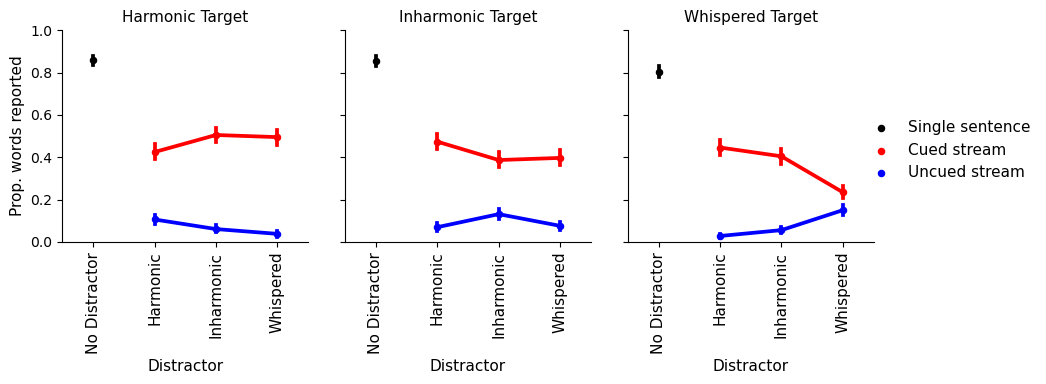

In [11]:
order = ["No Distractor", 'Harmonic', 'Inharmonic', 'Whispered']


hues = ['k', 'r', 'b']
hue_order = ['Single sentence', 'Cued stream', 'Uncued stream']
fontsize=11


g = sns.catplot(kind='point',
    data=melted_results,
    col='target_condition', y='hits',
    hue = 'attended_stream', hue_order=hue_order,
    palette=hues,
    order = order,
    markers='.',
    x='distractor_condition',
#     hue='distractor_condition', hue_order=hue_order, palette=distractor_palette,
#     col='subject',
    seed=1, 
    errorbar=('ci', 95),
    height=3, aspect=1
)


g.set_axis_labels("Distractor", "Prop. words reported", size=fontsize)
g.set_xticklabels(rotation=90, size=fontsize)
# g.set_xticklabels(rotation=0, size=fontsize)

# g.set_yticklabels(size=fontsize)

g.set_titles("{col_name} Target", size=fontsize)
g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='', 
                loc="center right", bbox_to_anchor=(1, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)

plt.ylim(0,1)
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
# g.fig.suptitle('Best binaural model performance on \ninharmonic and whispered speech', size=fontsize)
# g.fig.tight_layout()


Text(0.5, 0.98, 'Model performance on \ninharmonic and whispered speech')

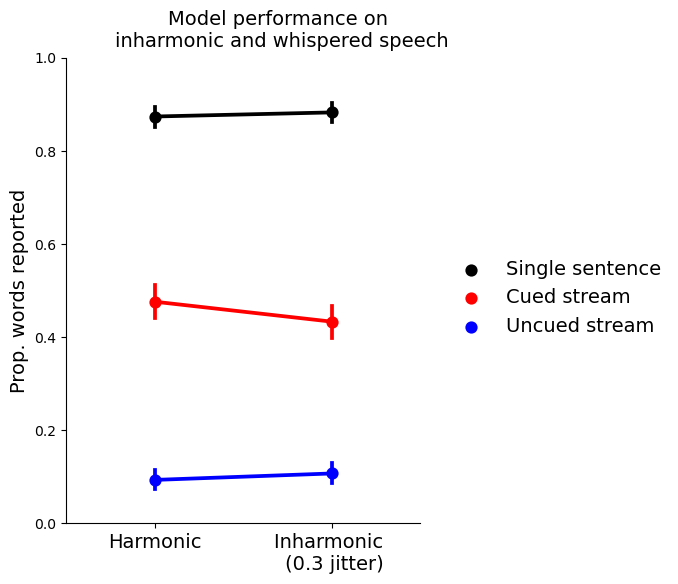

In [38]:
order = ['Harmonic', 'Inharmonic \n (0.3 jitter)']


hues = ['k', 'r', 'b']
hue_order = ['Single sentence', 'Cued stream', 'Uncued stream']
fontsize=14


g = sns.catplot(kind='point',
    data=spch_rslts,
    x='distractor_condition', y='hits',
    hue = 'attended_stream', hue_order=hue_order,
    palette=hues,
    order = order,
#     hue='distractor_condition', hue_order=hue_order, palette=distractor_palette,
#     col='subject',
    seed=1, 
    height=6, aspect=0.75
)


g.set_axis_labels("", "Prop. words reported", size=fontsize)
g.set_xticklabels(rotation=0, size=fontsize)
# g.set_xticklabels(rotation=0, size=fontsize)

# g.set_yticklabels(size=fontsize)

# g.set_titles("{col_name} performance", size=fontsize)
g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='', 
                loc="center right", bbox_to_anchor=(1.15, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)

plt.ylim(0,1)
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Model performance on \ninharmonic and whispered speech', size=fontsize)
# g.fig.tight_layout()

In [167]:
melted_results.distractor_condition.unique()

array(['Harmonic', 'No Distractor', 'Inharmonic', 'Whispered'],
      dtype=object)

In [176]:
to_plot.distractor_condition.unique()

array(['Harmonic', 'Harmonic Clean', 'Whispered', 'Whispered Clean',
       'Inharmonic \n (0.3 jitter)', 'Inharmonic \n (0.3 jitter) Clean'],
      dtype=object)

In [191]:
all_results.columns

Index(['true_word_ix', 'orig_df_ix', 'model_confidence', 'accuracy',
       'pred_word_ix', 'target_condition', 'distractor_condition',
       'distractor_condition_str', 'guessed_word', 'true_word',
       'distractor_words', 'distractor_sex', 'snr', 'target_sex', 'confusion'],
      dtype='object')

In [196]:
order = ['Harmonic', 'Inharmonic', 'Whispered']
# order = ['Harmonic', 'Inharmonic \n (0.3 jitter)', 'Whispered']

to_plot = all_results.copy()
to_plot.loc[to_plot.distractor_condition == 'No distractor', 'distractor_condition'] = to_plot.loc[to_plot.distractor_condition == 'No distractor', 'target_condition']
to_plot = pd.melt(to_plot, id_vars=['distractor_condition'],
        value_vars=['accuracy', 'confusion'],
        value_name = 'hits',
        var_name = 'attended_stream')

to_plot['attended_stream'][to_plot['attended_stream'] == 'accuracy'] = "Cued stream"
to_plot['attended_stream'][to_plot['attended_stream'] == 'confusion']= "Uncued stream"
to_plot['attended_stream'][to_plot['distractor_condition'] == 'No Distractor']= "Single sentence"

to_plot['distractor_condition'] = to_plot['distractor_condition'].apply(lambda x: x.replace(' Clean', ''))

hues = ['k', 'r', 'b']
hue_order = ['Single sentence', 'Cued stream', 'Uncued stream']
fontsize=11


g = sns.catplot(kind='point',
    data=to_plot,
    x='distractor_condition', y='hits',
    hue = 'attended_stream', hue_order=hue_order,
    palette=hues,
    order = order,
    markers='.',
#     hue='distractor_condition', hue_order=hue_order, palette=distractor_palette,
#     col='subject',
    seed=1, 
    height=5, aspect=0.75
)


g.set_axis_labels("", "Prop. words reported", size=fontsize)
g.set_xticklabels(rotation=0, size=fontsize)
# g.set_xticklabels(rotation=0, size=fontsize)

# g.set_yticklabels(size=fontsize)

# g.set_titles("{col_name} performance", size=fontsize)
g.legend.set_title("")
# plt.yscale('log')
sns.move_legend(g, title='', 
                loc="center right", bbox_to_anchor=(1.15, .5),
                frameon=False, title_size=fontsize, fontsize=fontsize)
# plt.tick_params(axis='both', which='major', labelsize=16)

plt.ylim(0,1)
g.fig.subplots_adjust(top=0.9) # adjust the Figure in rp
g.fig.suptitle('Best binaural model performance on \ninharmonic and whispered speech', size=fontsize)
# g.fig.tight_layout()


/tmp/ipykernel_46381/2912267429.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['attended_stream'][to_plot['attended_stream'] == 'accuracy'] = "Cued stream"
/tmp/ipykernel_46381/2912267429.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['attended_stream'][to_plot['attended_stream'] == 'confusion']= "Uncued stream"
/tmp/ipykernel_46381/2912267429.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot['att

KeyError: 'target_condition'